# Retrain the three principal denoisers from scratch

This notebook performs the longer training:

- **U-TV:** 200 epochs, 64 unrolled PDHG iterations.
- **U-TGV:** 100 epochs, 64 unrolled PDHG iterations.
- **U-Tikhonov T16/CG32:** 200 epochs, bounded sigmoid map with $\lambda_{\max}=16\lambda^*$ and 32 unrolled CG iterations.

All three models retain the existing $256\times256$ preprocessing, 500/50 SeaTurtle split, stochastic training noise, deterministic validation corruptions, small U-Net architecture, AdamW optimiser and reconstruction MSE loss. Each run starts from a newly initialised model. The training pipeline writes a latest checkpoint after every epoch and separately preserves the checkpoint with the highest validation PSNR.

The runs use new checkpoint directories. The original 20-epoch checkpoints are never loaded, resumed or overwritten. The three long training calls are deliberately placed in separate cells, so a completed model remains safely stored before the next model starts.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def locate_project_root() -> Path:
    """Find cleaned_pipeline regardless of where Jupyter was launched."""
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
from argparse import Namespace
import gc

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from scripts.train_u_tv import train_u_tv
from scripts.train_u_tgv import train_u_tgv
from scripts.train_u_tikhonov import (
    load_reference_lambda,
    train_u_tikhonov,
)
from src.training.denoising import build_seaturtle_loaders, get_device

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.12.0
Device: mps


## Long-run scalar reference and data setup
Validates the data and scalar-baseline inputs, loads the calibrated lambda, and defines the common epoch target and protected checkpoint directories for the three principal retraining runs.

In [3]:
SEA_TURTLE_ROOT = Path(
    "/Users/kyrillguba/.cache/kagglehub/datasets/"
    "wildlifedatasets/seaturtleid2022/versions/4"
).expanduser()
SCALAR_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "tikhonov"
    / "scalar_tikhonov_baseline_summary.csv"
)

if not SEA_TURTLE_ROOT.is_dir():
    raise FileNotFoundError(
        f"SeaTurtle root not found: {SEA_TURTLE_ROOT}. "
        "Edit SEA_TURTLE_ROOT before continuing."
    )
if not SCALAR_SUMMARY_PATH.is_file():
    raise FileNotFoundError(
        f"Missing scalar baseline: {SCALAR_SUMMARY_PATH}. "
        "Run notebook 03 first."
    )

scalar_summary = pd.read_csv(SCALAR_SUMMARY_PATH)
reference_lambda = float(load_reference_lambda(SCALAR_SUMMARY_PATH))
recommended_cg_iters = int(
    scalar_summary.iloc[0].get("recommended_fixed_cg_iters", 32)
)
if recommended_cg_iters != 32:
    raise RuntimeError(
        "The principal configuration requires CG32, but the scalar summary "
        f"recommends CG{recommended_cg_iters}."
    )

OLD_CHECKPOINT_DIRS = {
    "U-TV (20 epochs)": PROJECT_ROOT / "checkpoints" / "u_tv",
    "U-TGV (20 epochs)": PROJECT_ROOT / "checkpoints" / "u_tgv",
    "U-Tikhonov T16/CG32 (20 epochs)": (
        PROJECT_ROOT / "checkpoints" / "u_tikhonov_bounded_x16_cg32"
    ),
}
NEW_CHECKPOINT_DIRS = {
    "U-TV": PROJECT_ROOT / "checkpoints" / "u_tv_e200_from_scratch",
    "U-TGV": PROJECT_ROOT / "checkpoints" / "u_tgv_e100_from_scratch",
    "U-Tikhonov T16/CG32": (
        PROJECT_ROOT
        / "checkpoints"
        / "u_tikhonov_bounded_x16_cg32_e200_from_scratch"
    ),
}
RESULTS_DIR = PROJECT_ROOT / "results" / "training" / "principal_long_runs"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

old_resolved = {path.resolve() for path in OLD_CHECKPOINT_DIRS.values()}
new_resolved = {path.resolve() for path in NEW_CHECKPOINT_DIRS.values()}
assert old_resolved.isdisjoint(new_resolved)
assert len(new_resolved) == len(NEW_CHECKPOINT_DIRS)

print("Reference scalar lambda:", reference_lambda)
print("T16 upper bound:", 16.0 * reference_lambda)
display(
    pd.DataFrame(
        [
            {"run": name, "path": str(path), "exists": path.exists()}
            for name, path in OLD_CHECKPOINT_DIRS.items()
        ]
    )
)
display(scalar_summary)

Reference scalar lambda: 2.080083823051904
T16 upper bound: 33.281341168830465


,run,path,exists
0,U-TV (20 epochs),/Users/kyrillguba/Documents/Data Analytics MSc...,True
1,U-TGV (20 epochs),/Users/kyrillguba/Documents/Data Analytics MSc...,True
2,U-Tikhonov T16/CG32 (20 epochs),/Users/kyrillguba/Documents/Data Analytics MSc...,True


,best_scalar_lambda,validation_mse,validation_psnr,validation_ssim,average_converged_cg_iters,minimum_converged_cg_iters,maximum_converged_cg_iters,recommended_fixed_cg_iters,validation_sigma,validation_noise_seed
0,2.080084,0.001103,29.932832,0.775427,26.44,25,28,32,0.1,10000


## Long-run safety and verification helpers
Defines safeguards against overwriting earlier experiments, checkpoint-loading checks, completed-run validation, and accelerator-memory cleanup.

In [4]:
MODEL_FILENAMES = {
    "U-TV": "u_tv",
    "U-TGV": "u_tgv",
    "U-Tikhonov T16/CG32": "u_tikhonov",
}


def require_fresh_run_directory(path: Path, method: str) -> None:
    """Refuse to overwrite any contents from an earlier long-run attempt."""
    path = path.resolve()
    if path in old_resolved:
        raise RuntimeError(f"Refusing to write {method} into protected directory: {path}")
    if path.exists() and any(path.iterdir()):
        raise FileExistsError(
            f"Long-run directory is not empty: {path}. "
            "This notebook never resumes or overwrites a run. If that model "
            "already completed, skip its training cell. Otherwise choose a new "
            "directory name before restarting it from scratch."
        )


def load_checkpoint_payload(path: Path) -> dict:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def verify_completed_run(method: str, checkpoint_dir: Path, expected_epochs: int) -> dict:
    stem = MODEL_FILENAMES[method]
    history_path = checkpoint_dir / "history.csv"
    summary_path = checkpoint_dir / "training_summary.csv"
    best_path = checkpoint_dir / f"{stem}_best.pth"
    latest_path = checkpoint_dir / f"{stem}_latest.pth"
    for path in (history_path, summary_path, best_path, latest_path):
        if not path.is_file():
            raise FileNotFoundError(f"Expected completed-run artifact: {path}")

    history = pd.read_csv(history_path)
    if len(history) != expected_epochs:
        raise RuntimeError(
            f"{method} has {len(history)} history rows, expected {expected_epochs}."
        )
    expected_best_index = int(history["val_psnr"].idxmax())
    expected_best_epoch = int(history.loc[expected_best_index, "epoch"])
    expected_best_psnr = float(history.loc[expected_best_index, "val_psnr"])

    best_payload = load_checkpoint_payload(best_path)
    latest_payload = load_checkpoint_payload(latest_path)
    if int(best_payload["epoch"]) != expected_best_epoch:
        raise RuntimeError(
            f"{method} best checkpoint epoch {best_payload['epoch']} does not "
            f"match the history maximum at epoch {expected_best_epoch}."
        )
    if int(latest_payload["epoch"]) != expected_epochs:
        raise RuntimeError(
            f"{method} latest checkpoint is epoch {latest_payload['epoch']}, "
            f"expected {expected_epochs}."
        )

    return {
        "method": method,
        "epochs_run": expected_epochs,
        "best_epoch": expected_best_epoch,
        "best_val_psnr": expected_best_psnr,
        "best_checkpoint": str(best_path),
        "latest_checkpoint": str(latest_path),
    }


def release_accelerator_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()

## Experiment configuration
This collects the dataset, architecture, solver, optimisation, noise, seed, and output settings into the namespace consumed by the training pipeline.

In [5]:
COMMON_TRAINING = dict(
    data_root=str(SEA_TURTLE_ROOT),
    image_size=256,
    max_images=550,
    val_images=50,
    sigma_min=0.0,
    sigma_max=0.2,
    val_sigma=0.1,
    val_noise_seed=10_000,
    base_channels=32,
    depth=3,
    batch_size=1,
    lr=1e-4,
    weight_decay=1e-5,
    grad_clip=1.0,
    num_workers=0,
    print_every=50,
    seed=42,
    device=None,
    clamp_for_metrics=True,
)

args_tv = Namespace(
    **COMMON_TRAINING,
    checkpoint_dir=str(NEW_CHECKPOINT_DIRS["U-TV"]),
    epochs=200,
    num_pdhg_iters=64,
    map_scale=0.1,
    pdhg_tau=None,
    pdhg_sigma=None,
    pdhg_theta=None,
)
args_tgv = Namespace(
    **COMMON_TRAINING,
    checkpoint_dir=str(NEW_CHECKPOINT_DIRS["U-TGV"]),
    epochs=100,
    num_pdhg_iters=64,
    map_scale=0.1,
    pdhg_tau=None,
    pdhg_sigma=None,
    pdhg_theta=None,
)
args_tikhonov = Namespace(
    **COMMON_TRAINING,
    checkpoint_dir=str(NEW_CHECKPOINT_DIRS["U-Tikhonov T16/CG32"]),
    epochs=200,
    cg_iters=32,
    cg_relative_tol=1e-7,
    reference_lambda=reference_lambda,
    scalar_baseline_summary=str(SCALAR_SUMMARY_PATH),
    map_scale=None,
    lambda_parameterization="bounded_sigmoid",
    lambda_min=1e-4,
    lambda_max=16.0 * reference_lambda,
)

configuration_table = pd.DataFrame(
    [
        {
            "method": "U-TV",
            "epochs": args_tv.epochs,
            "solver": "PDHG64",
            "checkpoint_dir": args_tv.checkpoint_dir,
        },
        {
            "method": "U-TGV",
            "epochs": args_tgv.epochs,
            "solver": "PDHG64",
            "checkpoint_dir": args_tgv.checkpoint_dir,
        },
        {
            "method": "U-Tikhonov T16/CG32",
            "epochs": args_tikhonov.epochs,
            "solver": "CG32",
            "checkpoint_dir": args_tikhonov.checkpoint_dir,
        },
    ]
)
display(configuration_table)

,method,epochs,solver,checkpoint_dir
0,U-TV,200,PDHG64,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-TGV,100,PDHG64,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T16/CG32,200,CG32,/Users/kyrillguba/Documents/Data Analytics MSc...


This cell builds the deterministic train and validation loaders and verifies sample counts, splits, noise levels, and pairing assumptions.

In [6]:
train_loader_tv, val_loader_tv = build_seaturtle_loaders(args_tv)
train_loader_tgv, val_loader_tgv = build_seaturtle_loaders(args_tgv)
train_loader_tikh, val_loader_tikh = build_seaturtle_loaders(args_tikhonov)

train_loaders = [train_loader_tv, train_loader_tgv, train_loader_tikh]
val_loaders = [val_loader_tv, val_loader_tgv, val_loader_tikh]

assert all(len(loader.dataset) == 500 for loader in train_loaders)
assert all(len(loader.dataset) == 50 for loader in val_loaders)

train_indices = [tuple(loader.dataset.indices) for loader in train_loaders]
val_indices = [tuple(loader.dataset.dataset.indices) for loader in val_loaders]
assert train_indices[0] == train_indices[1] == train_indices[2]
assert val_indices[0] == val_indices[1] == val_indices[2]

base_paths = [
    tuple(str(path) for path in loader.dataset.dataset.image_paths)
    for loader in train_loaders
]
assert base_paths[0] == base_paths[1] == base_paths[2]

for index in range(50):
    samples = [loader.dataset[index] for loader in val_loaders]
    assert samples[0]["path"] == samples[1]["path"] == samples[2]["path"]
    assert torch.equal(samples[0]["clean"], samples[1]["clean"])
    assert torch.equal(samples[0]["clean"], samples[2]["clean"])
    assert torch.equal(samples[0]["noisy"], samples[1]["noisy"])
    assert torch.equal(samples[0]["noisy"], samples[2]["noisy"])
    assert float(samples[0]["sigma"].item()) == float(samples[1]["sigma"].item())
    assert float(samples[0]["sigma"].item()) == float(samples[2]["sigma"].item())

print("Training split identity verified across all three runs: 500 images.")
print("Validation tensor identity verified across all three runs: 50 images.")
print("Validation sigma:", float(val_loader_tv.dataset[0]["sigma"].item()))
print("Validation noise seed:", args_tv.val_noise_seed)

Training split identity verified across all three runs: 500 images.
Validation tensor identity verified across all three runs: 50 images.
Validation sigma: 0.10000000149011612
Validation noise seed: 10000


## Long training runs

Each call creates a new model from scratch and resets the configured random seed.
The object returned by each training function is the **final-epoch** model.

### U-Tikhonov T16/CG32

In [7]:
require_fresh_run_directory(
    NEW_CHECKPOINT_DIRS["U-Tikhonov T16/CG32"],
    "U-Tikhonov T16/CG32",
)

model_tikh_long, history_tikh_long = train_u_tikhonov(
    args_tikhonov,
    train_loader=train_loader_tikh,
    val_loader=val_loader_tikh,
)
display(history_tikh_long.tail())
tikh_verification = verify_completed_run(
    "U-Tikhonov T16/CG32",
    NEW_CHECKPOINT_DIRS["U-Tikhonov T16/CG32"],
    expected_epochs=200,
)
display(pd.DataFrame([tikh_verification]))

del model_tikh_long
release_accelerator_memory()

Using device: mps
Model: u_tikhonov | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.958152e-03
Epoch 001 | batch 0100/0500 | train MSE 6.435108e-04
Epoch 001 | batch 0150/0500 | train MSE 1.457181e-04
Epoch 001 | batch 0200/0500 | train MSE 1.717404e-03
Epoch 001 | batch 0250/0500 | train MSE 2.393768e-03
Epoch 001 | batch 0300/0500 | train MSE 1.391148e-03
Epoch 001 | batch 0350/0500 | train MSE 2.201921e-03
Epoch 001 | batch 0400/0500 | train MSE 1.104022e-03
Epoch 001 | batch 0450/0500 | train MSE 1.373187e-03
Epoch 001 | batch 0500/0500 | train MSE 3.291636e-03
Epoch 001 | train MSE 1.228823e-03 | val MSE 1.132845e-03 | val PSNR 29.972 | val SSIM 0.7950 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.363503e-03
Epoch 002 | batch 0100/0500 | train MSE 8.020446e-04
Epoch 002 | batch 0150/0500 | train MSE 1.170303e-03
Epoch 002 | batch 0200/0500 | train MSE 1.334741e-03
Epoch 002 | batch 0250/0500 | train MSE 4.333142e-0

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99,val_lambda_lower_saturation_fraction,val_lambda_upper_saturation_fraction
195,196,0.000673,0.000695,32.099378,0.876999,0.009698,20.136563,0.322267,75.221428,4.738345,...,10.552207,15.375522,11.608299,0.004649,33.281342,0.492604,12.708233,33.208991,0.014691,0.250393
196,197,0.000706,0.000691,32.123541,0.879378,0.009698,20.136563,0.322267,75.196680,4.697249,...,10.644528,14.039114,11.215934,0.005026,33.281342,0.404150,10.727800,32.984947,0.021918,0.200551
197,198,0.000660,0.000691,32.124858,0.880121,0.009698,20.136563,0.322267,74.929251,4.707461,...,10.621436,14.446908,11.727911,0.005522,33.281342,0.401634,11.047326,33.200760,0.021145,0.237162
198,199,0.000659,0.000693,32.113649,0.877908,0.009698,20.136563,0.322267,75.064390,4.685552,...,10.671100,15.920462,11.938965,0.007258,33.281342,0.464487,13.493248,33.260660,0.015644,0.266857
199,200,0.000627,0.000692,32.115645,0.880105,0.009698,20.136563,0.322267,74.925873,4.707456,...,10.621448,14.285046,11.817230,0.008114,33.281342,0.407896,10.678346,33.106686,0.019482,0.233159


,method,epochs_run,best_epoch,best_val_psnr,best_checkpoint,latest_checkpoint
0,U-Tikhonov T16/CG32,200,185,32.12489,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


### U-TV

In [8]:
require_fresh_run_directory(NEW_CHECKPOINT_DIRS["U-TV"], "U-TV")

model_tv_long, history_tv_long = train_u_tv(
    args_tv,
    train_loader=train_loader_tv,
    val_loader=val_loader_tv,
)
display(history_tv_long.tail())
tv_verification = verify_completed_run(
    "U-TV",
    NEW_CHECKPOINT_DIRS["U-TV"],
    expected_epochs=200,
)
display(pd.DataFrame([tv_verification]))

del model_tv_long
release_accelerator_memory()

Using device: mps
Model: u_tv | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.797069e-03
Epoch 001 | batch 0100/0500 | train MSE 1.068086e-03
Epoch 001 | batch 0150/0500 | train MSE 4.855778e-04
Epoch 001 | batch 0200/0500 | train MSE 1.354327e-03
Epoch 001 | batch 0250/0500 | train MSE 2.220343e-03
Epoch 001 | batch 0300/0500 | train MSE 1.122797e-03
Epoch 001 | batch 0350/0500 | train MSE 2.225133e-03
Epoch 001 | batch 0400/0500 | train MSE 8.085020e-04
Epoch 001 | batch 0450/0500 | train MSE 1.268352e-03
Epoch 001 | batch 0500/0500 | train MSE 2.950514e-03
Epoch 001 | train MSE 1.238543e-03 | val MSE 1.079137e-03 | val PSNR 30.334 | val SSIM 0.8188 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 1.496368e-03
Epoch 002 | batch 0100/0500 | train MSE 8.523644e-04
Epoch 002 | batch 0150/0500 | train MSE 1.475759e-03
Epoch 002 | batch 0200/0500 | train MSE 9.465595e-04
Epoch 002 | batch 0250/0500 | train MSE 4.786474e-04
Epoc

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,total_time_sec,train_images_per_sec,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99
195,196,0.000698,0.000729,31.903031,0.872157,0.009698,20.136563,0.322267,72.727924,3.213571,...,14902.453304,6.874938,15.559013,0.103489,0.100216,0.000141,1.024980,0.010505,0.068798,0.481482
196,197,0.000730,0.000719,31.953274,0.875364,0.009698,20.136563,0.322267,72.662508,3.262302,...,14978.435730,6.881128,15.326600,0.099174,0.093573,0.000104,0.986545,0.009121,0.067238,0.449774
197,198,0.000684,0.000720,31.948387,0.876029,0.009698,20.136563,0.322267,72.726113,3.269682,...,15054.538115,6.875110,15.292005,0.094031,0.090003,0.000141,1.017618,0.008680,0.063891,0.439073
198,199,0.000682,0.000726,31.914694,0.872401,0.009698,20.136563,0.322267,72.686837,3.258388,...,15130.540397,6.878825,15.345011,0.108751,0.101818,0.000184,1.076180,0.010483,0.072918,0.484823
199,200,0.000649,0.000721,31.943436,0.876410,0.009698,20.136563,0.322267,72.711365,3.271470,...,15206.578649,6.876504,15.283649,0.088697,0.082735,0.000143,1.012014,0.008606,0.061772,0.402936


,method,epochs_run,best_epoch,best_val_psnr,best_checkpoint,latest_checkpoint
0,U-TV,200,197,31.953274,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


### U-TGV

In [9]:
require_fresh_run_directory(NEW_CHECKPOINT_DIRS["U-TGV"], "U-TGV")

model_tgv_long, history_tgv_long = train_u_tgv(
    args_tgv,
    train_loader=train_loader_tgv,
    val_loader=val_loader_tgv,
)
display(history_tgv_long.tail())
tgv_verification = verify_completed_run(
    "U-TGV",
    NEW_CHECKPOINT_DIRS["U-TGV"],
    expected_epochs=100,
)
display(pd.DataFrame([tgv_verification]))

del model_tgv_long
release_accelerator_memory()

Using device: mps
Model: u_tgv | train images: 500 | validation images: 50
Epoch 001 | batch 0050/0500 | train MSE 1.401841e-03
Epoch 001 | batch 0100/0500 | train MSE 9.447266e-04
Epoch 001 | batch 0150/0500 | train MSE 2.379031e-04
Epoch 001 | batch 0200/0500 | train MSE 1.465478e-03
Epoch 001 | batch 0250/0500 | train MSE 1.946265e-03
Epoch 001 | batch 0300/0500 | train MSE 1.400386e-03
Epoch 001 | batch 0350/0500 | train MSE 1.058611e-03
Epoch 001 | batch 0400/0500 | train MSE 1.112386e-03
Epoch 001 | batch 0450/0500 | train MSE 1.168889e-03
Epoch 001 | batch 0500/0500 | train MSE 2.301762e-03
Epoch 001 | train MSE 1.161701e-03 | val MSE 1.017007e-03 | val PSNR 30.508 | val SSIM 0.8260 | noisy PSNR 20.137 | saved best
Epoch 002 | batch 0050/0500 | train MSE 3.827363e-04
Epoch 002 | batch 0100/0500 | train MSE 1.420600e-03
Epoch 002 | batch 0150/0500 | train MSE 2.584351e-03
Epoch 002 | batch 0200/0500 | train MSE 7.598570e-04
Epoch 002 | batch 0250/0500 | train MSE 4.135269e-04
Epo

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,val_lambda0_p01,val_lambda0_median,val_lambda0_p99,val_lambda1_mean,val_lambda1_std,val_lambda1_min,val_lambda1_max,val_lambda1_p01,val_lambda1_median,val_lambda1_p99
95,96,0.000812,0.000752,31.631691,0.857144,0.009698,20.136563,0.322267,184.612296,6.298956,...,0.018417,0.153835,0.530727,0.129518,0.063380,0.020894,0.477096,0.046567,0.110845,0.282822
96,97,0.000722,0.000753,31.629627,0.857440,0.009698,20.136563,0.322267,184.585416,6.269930,...,0.019829,0.111393,0.444513,0.111417,0.048694,0.021714,0.438555,0.048534,0.096003,0.242999
97,98,0.000738,0.000762,31.575253,0.859242,0.009698,20.136563,0.322267,184.161488,6.275455,...,0.015320,0.125810,0.495298,0.112677,0.056039,0.017036,0.456734,0.039513,0.096333,0.254586
98,99,0.000777,0.000753,31.628285,0.856429,0.009698,20.136563,0.322267,184.242898,6.260288,...,0.019734,0.131203,0.479049,0.113700,0.049989,0.021687,0.507646,0.046979,0.099281,0.249472
99,100,0.000761,0.000750,31.640771,0.858434,0.009698,20.136563,0.322267,185.937956,6.286053,...,0.018841,0.103164,0.391447,0.101524,0.041520,0.021772,0.512036,0.045260,0.090116,0.219610


,method,epochs_run,best_epoch,best_val_psnr,best_checkpoint,latest_checkpoint
0,U-TGV,100,100,31.640771,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


## Training history 
This combines the three training histories, marks each validation-selected checkpoint, plots U-Tikhonov map evolution, and saves the summary table.

,method,epochs_run,best_epoch,best_val_psnr,total_training_hours,mean_epoch_seconds,solver_iterations,best_checkpoint
0,U-TV,200,197,31.953274,4.224050,75.960275,64,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-TGV,100,100,31.640771,5.306386,190.956136,64,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T16/CG32,200,185,32.124890,4.456267,80.142094,32,/Users/kyrillguba/Documents/Data Analytics MSc...


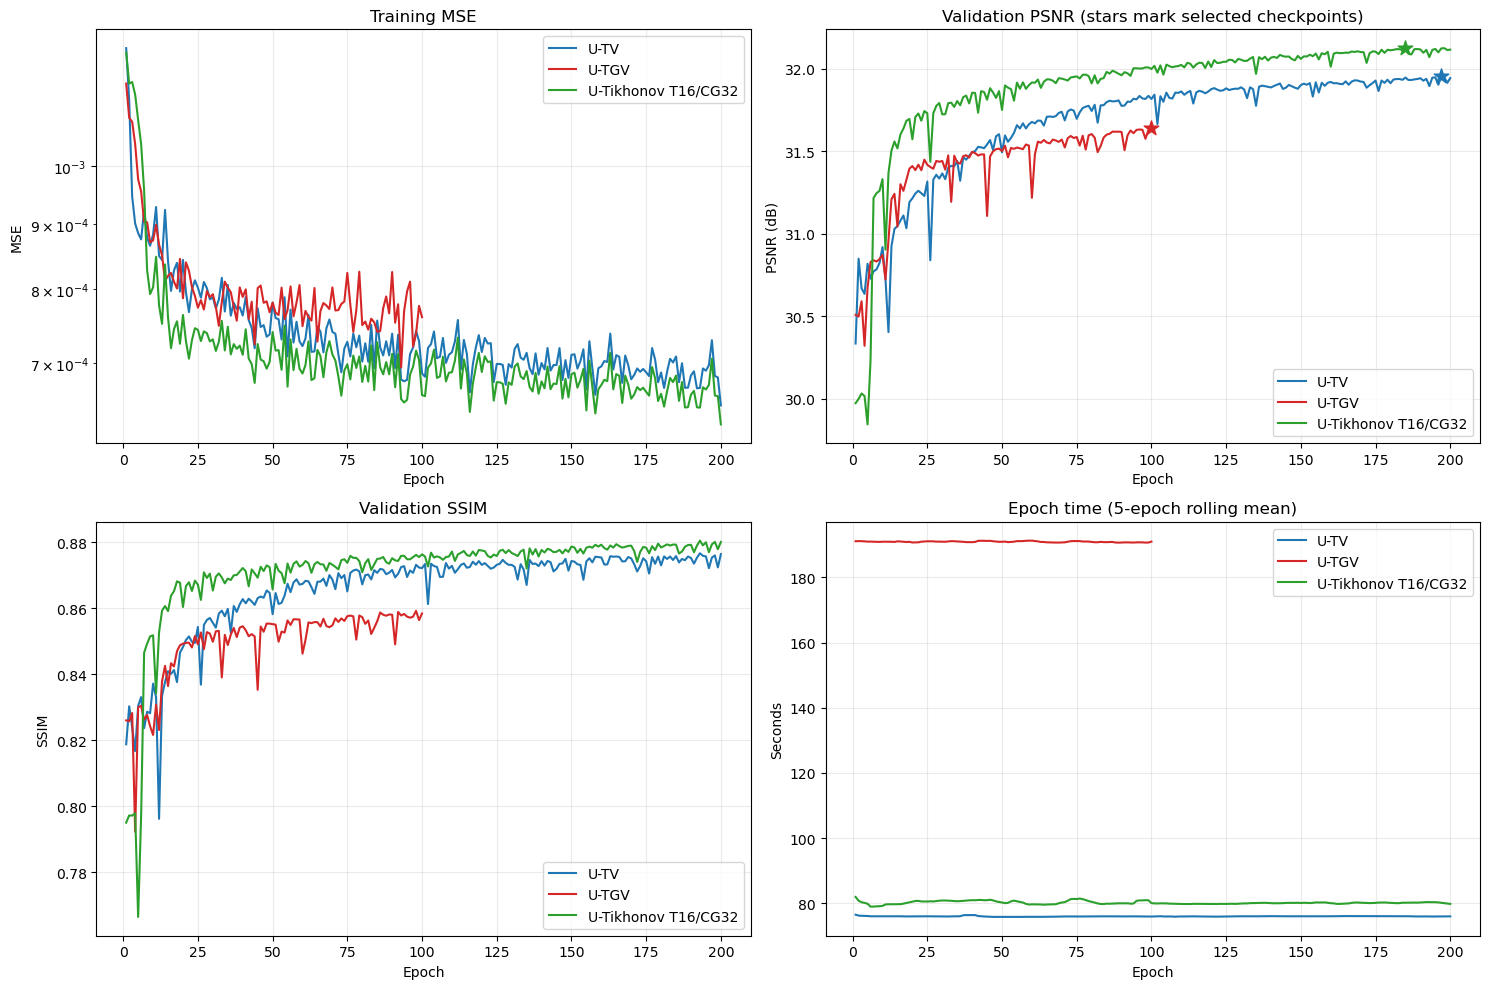

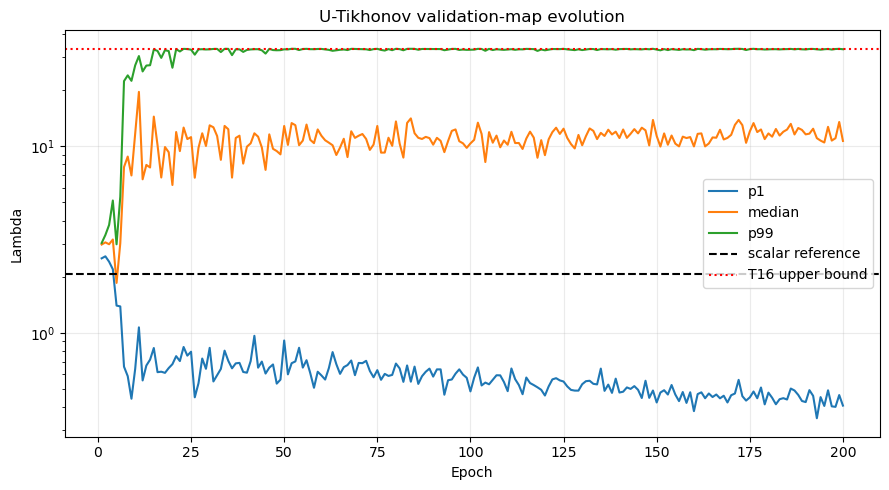

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/principal_long_runs/u_tikhonov_t16_cg32_long_parameter_evolution.png
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/principal_long_runs/principal_long_training_summary.csv
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/principal_long_runs/principal_long_training_curves.png
Use the three best_checkpoint paths above in the revised benchmark.


In [10]:
RUN_SPECS = {
    "U-TV": {"epochs": 200, "directory": NEW_CHECKPOINT_DIRS["U-TV"]},
    "U-TGV": {"epochs": 100, "directory": NEW_CHECKPOINT_DIRS["U-TGV"]},
    "U-Tikhonov T16/CG32": {
        "epochs": 200,
        "directory": NEW_CHECKPOINT_DIRS["U-Tikhonov T16/CG32"],
    },
}

histories = {}
verification_rows = []
for method, spec in RUN_SPECS.items():
    verification_rows.append(
        verify_completed_run(method, spec["directory"], spec["epochs"])
    )
    histories[method] = pd.read_csv(spec["directory"] / "history.csv")

verification_table = pd.DataFrame(verification_rows)
summary_rows = []
for method, spec in RUN_SPECS.items():
    timing = pd.read_csv(spec["directory"] / "training_summary.csv").iloc[0]
    verified = verification_table.loc[verification_table["method"] == method].iloc[0]
    summary_rows.append(
        {
            "method": method,
            "epochs_run": int(verified["epochs_run"]),
            "best_epoch": int(verified["best_epoch"]),
            "best_val_psnr": float(verified["best_val_psnr"]),
            "total_training_hours": float(timing["total_time_sec"]) / 3600.0,
            "mean_epoch_seconds": float(timing["mean_epoch_time_sec"]),
            "solver_iterations": int(timing["solver_iterations"]),
            "best_checkpoint": verified["best_checkpoint"],
        }
    )

long_run_summary = pd.DataFrame(summary_rows)
summary_path = RESULTS_DIR / "principal_long_training_summary.csv"
long_run_summary.to_csv(summary_path, index=False)
display(long_run_summary)

colors = {
    "U-TV": "#1f77b4",
    "U-TGV": "#d62728",
    "U-Tikhonov T16/CG32": "#2ca02c",
}
figure, axes = plt.subplots(2, 2, figsize=(15, 10))

for method, history in histories.items():
    color = colors[method]
    best_index = int(history["val_psnr"].idxmax())
    best_epoch = int(history.loc[best_index, "epoch"])
    axes[0, 0].plot(history["epoch"], history["train_mse"], label=method, color=color)
    axes[0, 1].plot(history["epoch"], history["val_psnr"], label=method, color=color)
    axes[0, 1].scatter(
        best_epoch,
        history.loc[best_index, "val_psnr"],
        marker="*",
        s=120,
        color=color,
        zorder=3,
    )
    axes[1, 0].plot(history["epoch"], history["val_ssim"], label=method, color=color)
    axes[1, 1].plot(
        history["epoch"],
        history["epoch_time_sec"].rolling(5, min_periods=1).mean(),
        label=method,
        color=color,
    )

axes[0, 0].set(title="Training MSE", xlabel="Epoch", ylabel="MSE", yscale="log")
axes[0, 1].set(title="Validation PSNR (stars mark selected checkpoints)", xlabel="Epoch", ylabel="PSNR (dB)")
axes[1, 0].set(title="Validation SSIM", xlabel="Epoch", ylabel="SSIM")
axes[1, 1].set(title="Epoch time (5-epoch rolling mean)", xlabel="Epoch", ylabel="Seconds")
for axis in axes.ravel():
    axis.grid(alpha=0.25)
    axis.legend()

figure.tight_layout()
curves_path = RESULTS_DIR / "principal_long_training_curves.png"
figure.savefig(curves_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)

tikh_history = histories["U-Tikhonov T16/CG32"]
lambda_columns = [
    ("val_lambda_p01", "p1"),
    ("val_lambda_median", "median"),
    ("val_lambda_p99", "p99"),
]
available_lambda_columns = [item for item in lambda_columns if item[0] in tikh_history]
if available_lambda_columns:
    figure, axis = plt.subplots(figsize=(9, 5))
    for column, label in available_lambda_columns:
        axis.plot(tikh_history["epoch"], tikh_history[column], label=label)
    axis.axhline(reference_lambda, color="black", linestyle="--", label="scalar reference")
    axis.axhline(16.0 * reference_lambda, color="red", linestyle=":", label="T16 upper bound")
    axis.set(
        title="U-Tikhonov validation-map evolution",
        xlabel="Epoch",
        ylabel="Lambda",
        yscale="log",
    )
    axis.grid(alpha=0.25)
    axis.legend()
    figure.tight_layout()
    lambda_path = RESULTS_DIR / "u_tikhonov_t16_cg32_long_parameter_evolution.png"
    figure.savefig(lambda_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print("Saved:", lambda_path)

print("Saved:", summary_path)
print("Saved:", curves_path)
print("Use the three best_checkpoint paths above in the revised benchmark.")